In [1]:
import pandas as pd

# Load data
df = pd.read_csv('Amazon Sale Report.csv', encoding='unicode_escape')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (128975, 24)

Columns: ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

First 5 rows:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3

C:\Users\abdo\AppData\Local\Temp\ipykernel_4464\839429818.py:4: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv', encoding='unicode_escape')


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Load data
df = pd.read_csv('Amazon Sale Report.csv', encoding='unicode_escape', low_memory=False)

# Clean data
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')
df = df.dropna(subset=['Amount', 'Date'])
df = df[df['Amount'] > 0]
df = df[df['Status'] != 'Cancelled']

print("✅ Data cleaned!")
print(f"Total orders after cleaning: {len(df)}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Total revenue: {df['Amount'].sum():,.2f} INR")

✅ Data cleaned!
Total orders after cleaning: 108071
Date range: 2022-03-31 00:00:00 → 2022-06-29 00:00:00
Total revenue: 71,673,394.00 INR


C:\Users\abdo\AppData\Local\Temp\ipykernel_4464\4009144740.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='Blues_d')


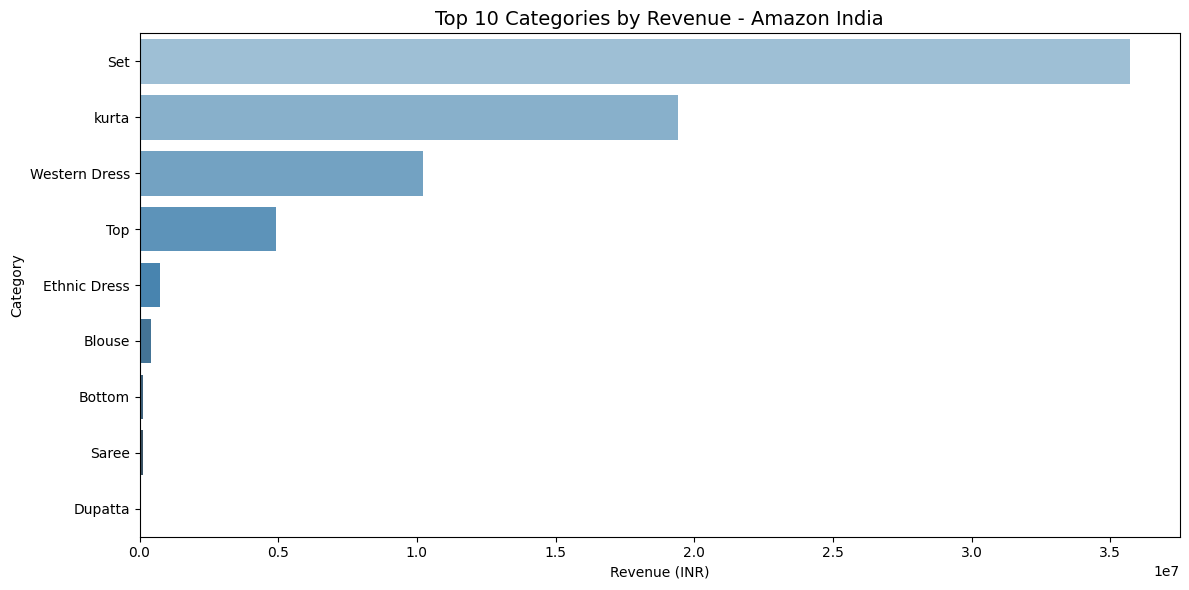

✅ chart_category.png saved!


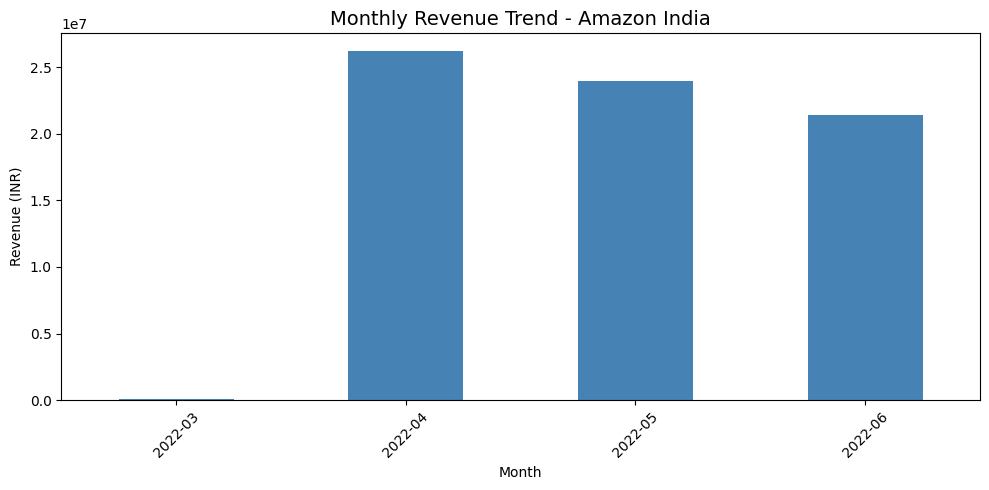

✅ chart_monthly.png saved!


C:\Users\abdo\AppData\Local\Temp\ipykernel_4464\4009144740.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values, y=state_sales.index, palette='Greens_d')


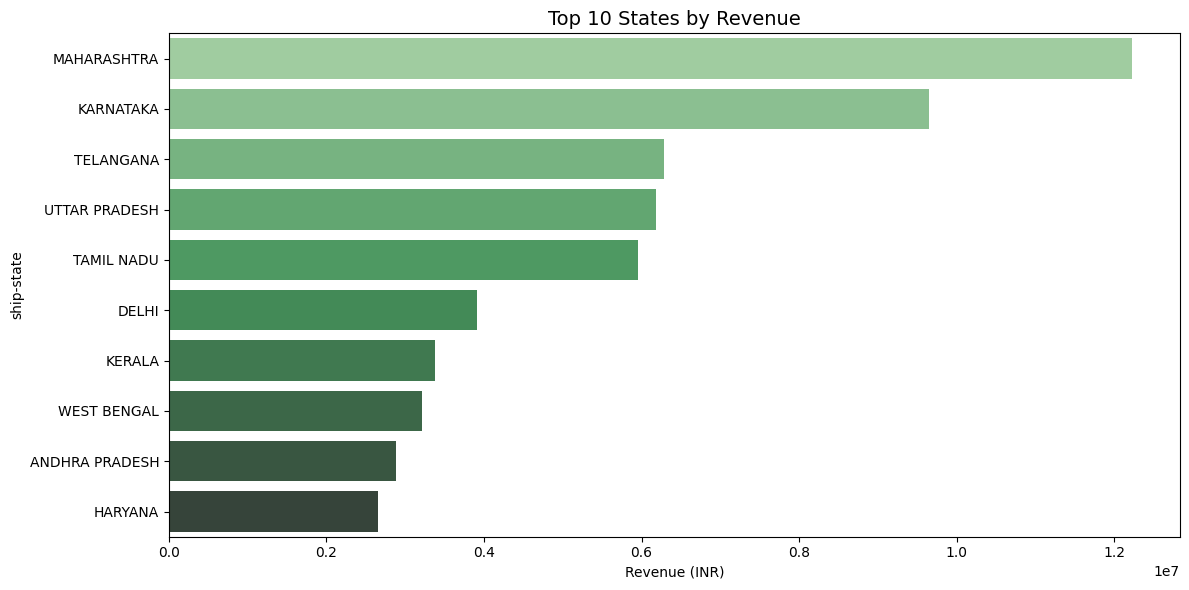

✅ chart_states.png saved!


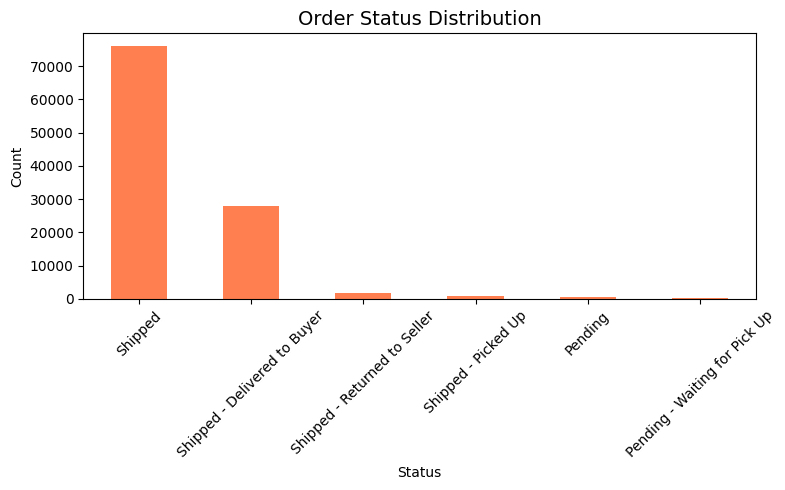

✅ chart_status.png saved!

🎉 All charts done!


In [3]:
# ============================
# 1. Sales by Category
# ============================
cat_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='Blues_d')
plt.title('Top 10 Categories by Revenue - Amazon India', fontsize=14)
plt.xlabel('Revenue (INR)')
plt.tight_layout()
plt.savefig('chart_category.png')
plt.show()
print("✅ chart_category.png saved!")

# ============================
# 2. Monthly Sales Trend
# ============================
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10, 5))
monthly.plot(kind='bar', color='steelblue')
plt.title('Monthly Revenue Trend - Amazon India', fontsize=14)
plt.ylabel('Revenue (INR)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_monthly.png')
plt.show()
print("✅ chart_monthly.png saved!")

# ============================
# 3. Sales by State
# ============================
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.values, y=state_sales.index, palette='Greens_d')
plt.title('Top 10 States by Revenue', fontsize=14)
plt.xlabel('Revenue (INR)')
plt.tight_layout()
plt.savefig('chart_states.png')
plt.show()
print("✅ chart_states.png saved!")

# ============================
# 4. Order Status Distribution
# ============================
status = df['Status'].value_counts().head(6)

plt.figure(figsize=(8, 5))
status.plot(kind='bar', color='coral')
plt.title('Order Status Distribution', fontsize=14)
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_status.png')
plt.show()
print("✅ chart_status.png saved!")

print("\n🎉 All charts done!")

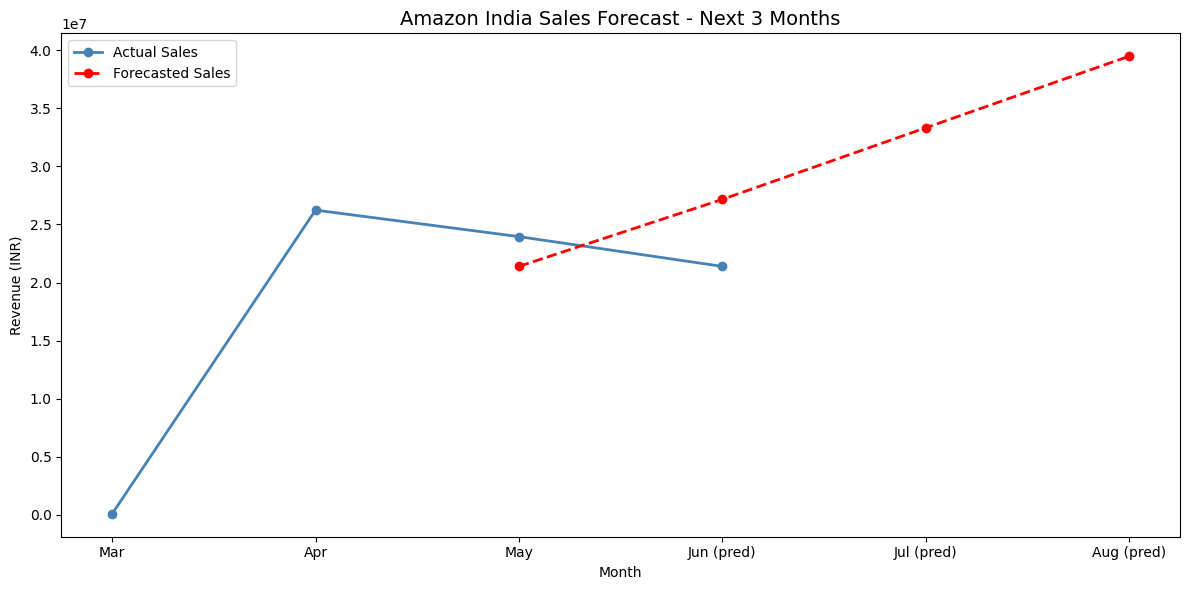


📈 Forecast Results:
  June 2022: 27,159,275 INR
  July 2022: 33,319,892 INR
  August 2022: 39,480,509 INR


In [4]:
# ============================
# AI Sales Forecasting
# ============================
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
monthly_data = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().reset_index()
monthly_data['Month_Num'] = range(len(monthly_data))

X = monthly_data['Month_Num'].values.reshape(-1, 1)
y = monthly_data['Amount'].values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 3 months
future_months = np.array([[3], [4], [5]])
predictions = model.predict(future_months)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_data['Month_Num'], y, marker='o', label='Actual Sales', color='steelblue', linewidth=2)
plt.plot([2, 3, 4, 5], 
         [y[-1]] + list(predictions), 
         marker='o', linestyle='--', 
         label='Forecasted Sales', color='red', linewidth=2)

plt.title('Amazon India Sales Forecast - Next 3 Months', fontsize=14)
plt.ylabel('Revenue (INR)')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5], ['Mar', 'Apr', 'May', 'Jun (pred)', 'Jul (pred)', 'Aug (pred)'])
plt.legend()
plt.tight_layout()
plt.savefig('chart_forecast.png')
plt.show()

print("\n📈 Forecast Results:")
months = ['June 2022', 'July 2022', 'August 2022']
for month, pred in zip(months, predictions):
    print(f"  {month}: {pred:,.0f} INR")

In [5]:
# ============================
# Summary Report
# ============================
print("=" * 50)
print("📊 AMAZON INDIA SALES ANALYSIS REPORT")
print("=" * 50)
print(f"\n📦 Total Orders Analyzed: {len(df):,}")
print(f"💰 Total Revenue: {df['Amount'].sum():,.0f} INR")
print(f"📅 Period: Mar 2022 → Jun 2022")
print(f"\n🏆 Top Category: {df.groupby('Category')['Amount'].sum().idxmax()}")
print(f"🌍 Top State: {df.groupby('ship-state')['Amount'].sum().idxmax()}")
print(f"📦 Avg Order Value: {df['Amount'].mean():,.0f} INR")
print(f"\n📈 AI Forecast:")
print(f"  June 2022:   27,159,275 INR")
print(f"  July 2022:   33,319,892 INR")
print(f"  August 2022: 39,480,509 INR")
print("\n✅ Analysis complete!")

📊 AMAZON INDIA SALES ANALYSIS REPORT

📦 Total Orders Analyzed: 108,071
💰 Total Revenue: 71,673,394 INR
📅 Period: Mar 2022 → Jun 2022

🏆 Top Category: Set
🌍 Top State: MAHARASHTRA
📦 Avg Order Value: 663 INR

📈 AI Forecast:
  June 2022:   27,159,275 INR
  July 2022:   33,319,892 INR
  August 2022: 39,480,509 INR

✅ Analysis complete!
